# Preprocessing Walkthrough for the Ensemble Pipeline

This notebook explains the preprocessing used before feature extraction in `ensemble_v2`.

The goal is to make the full path visible:
1. load and resize the image,
2. normalize color using LAB-based matching + CLAHE,
3. scan for candidate tissue patches,
4. score each patch by quality,
5. keep the best patches, and
6. visualize what the model actually sees.

The figures below are meant for viva preparation: they show the original image, the normalized image, the extracted patch candidates, and the top-ranked patches after quality filtering.

In [4]:
import os
import cv2
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# Use the same preprocessing assumptions as ensemble_v2
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CFG = {
    "image_resize": 512,
    "clahe_clip": 1.5,
    "clahe_grid": (16, 16),
    "patch_scales": [96, 128, 192],
    "patch_output": 224,
    "stride_frac": 0.5,
    "min_tissue": 0.40,
    "max_bright": 245,
    "min_bright": 15,
    "min_sat": 10,
    "min_focus": 8.0,
    "quality_frac": 0.85,
    "max_patches": 50,
}

PROJECT_ROOT = "/Applications/Projects/Bladder Research/Data"
DATA_ROOT = os.path.join(PROJECT_ROOT, "EndoscopicBladderTissue")
if not os.path.isdir(DATA_ROOT):
    alt_root = os.path.join(PROJECT_ROOT, "Model Training and Evaluation", "Ensemble", "EndoscopicBladderTissue")
    if os.path.isdir(alt_root):
        DATA_ROOT = alt_root

print(f"Data root: {DATA_ROOT}")

class LabNormalizer:
    def __init__(self):
        self.ref = None

    def fit(self, imgs):
        stats = {"L": [], "a": [], "b": []}
        for img in imgs:
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
            for i, ch in enumerate(["L", "a", "b"]):
                stats[ch].append({"m": lab[:, :, i].mean(), "s": lab[:, :, i].std() + 1e-6})
        self.ref = {
            ch: {
                "m": np.median([x["m"] for x in stats[ch]]),
                "s": np.median([x["s"] for x in stats[ch]]),
            }
            for ch in ["L", "a", "b"]
        }
        return self

    def transform(self, img):
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
        for i, ch in enumerate(["L", "a", "b"]):
            c = lab[:, :, i]
            sm, ss = c.mean(), c.std() + 1e-6
            lab[:, :, i] = np.clip((c - sm) * (self.ref[ch]["s"] / ss) + self.ref[ch]["m"], 0, 255)
        lab = lab.astype(np.uint8)
        lab[:, :, 0] = cv2.createCLAHE(
            clipLimit=CFG["clahe_clip"],
            tileGridSize=CFG["clahe_grid"],
        ).apply(lab[:, :, 0])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


def load_image(path, norm=None):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    h, w = img.shape[:2]
    scale = CFG["image_resize"] / max(h, w)
    if scale != 1:
        img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
    return norm.transform(img) if norm else img


def patch_quality(p):
    hsv = cv2.cvtColor(p, cv2.COLOR_BGR2HSV)
    v = hsv[:, :, 2].astype(np.float32)
    s = hsv[:, :, 1].astype(np.float32)
    mask = (v < CFG["max_bright"]) & (v > CFG["min_bright"]) & (s > CFG["min_sat"])
    tissue_frac = mask.sum() / mask.size
    if tissue_frac < CFG["min_tissue"]:
        return -1.0

    gray = cv2.cvtColor(p, cv2.COLOR_BGR2GRAY)
    focus = cv2.Laplacian(gray, cv2.CV_64F).var()
    if focus < CFG["min_focus"]:
        return -1.0

    sat_std = s[mask].std() / 50 if mask.sum() > 10 else 0
    edge_density = cv2.Canny(gray, 50, 150).sum() / (255 * gray.size) * 10
    return 0.3 * tissue_frac + 0.3 * min(focus / 100, 1) + 0.2 * min(sat_std, 1) + 0.2 * min(edge_density, 1)


def extract_patches(img, maxp=None):
    if maxp is None:
        maxp = CFG["max_patches"]
    h, w = img.shape[:2]
    candidates = []
    cap = maxp * 3

    for scale in CFG["patch_scales"]:
        if scale > min(h, w):
            continue
        stride = max(1, int(scale * CFG["stride_frac"]))
        for y in range(0, h - scale + 1, stride):
            for x in range(0, w - scale + 1, stride):
                if len(candidates) >= cap:
                    break
                crop = img[y:y + scale, x:x + scale]
                q = patch_quality(crop)
                if q > 0:
                    resized = cv2.resize(crop, (CFG["patch_output"], CFG["patch_output"]), interpolation=cv2.INTER_AREA)
                    candidates.append((resized, q, (x, y, scale)))
            if len(candidates) >= cap:
                break
        if len(candidates) >= cap:
            break

    if not candidates:
        return []

    candidates.sort(key=lambda item: item[1], reverse=True)
    keep_n = max(1, int(len(candidates) * CFG["quality_frac"]))
    return candidates[:keep_n][:maxp]


def find_sample_image(root):
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            if fn.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
                return os.path.join(dirpath, fn)
    return None


def collect_sample_images(root, limit=12):
    found = []
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            if fn.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
                found.append(os.path.join(dirpath, fn))
                if len(found) >= limit:
                    return found
    return found

sample_paths = collect_sample_images(DATA_ROOT, limit=12)
sample_path = sample_paths[0] if sample_paths else None
print(f"Sample image: {sample_path}")

if sample_path is not None:
    raw_img = load_image(sample_path, norm=None)
    fit_imgs = []
    for fp in sample_paths:
        try:
            fit_imgs.append(load_image(fp, norm=None))
        except Exception:
            continue
    normalizer = LabNormalizer().fit(fit_imgs if fit_imgs else [raw_img])
    norm_img = load_image(sample_path, norm=normalizer)
    patches = extract_patches(norm_img)
    print(f"Images used to fit normalizer: {len(fit_imgs) if fit_imgs else 1}")
    print(f"Extracted patches: {len(patches)}")
else:
    raw_img = None
    norm_img = None
    patches = []
    print("No image found in DATA_ROOT.")

Data root: /Applications/Projects/Bladder Research/Data/EndoscopicBladderTissue
Sample image: /Applications/Projects/Bladder Research/Data/EndoscopicBladderTissue/NST/cys_case_5_pt2_0083.png
Images used to fit normalizer: 12
Extracted patches: 50


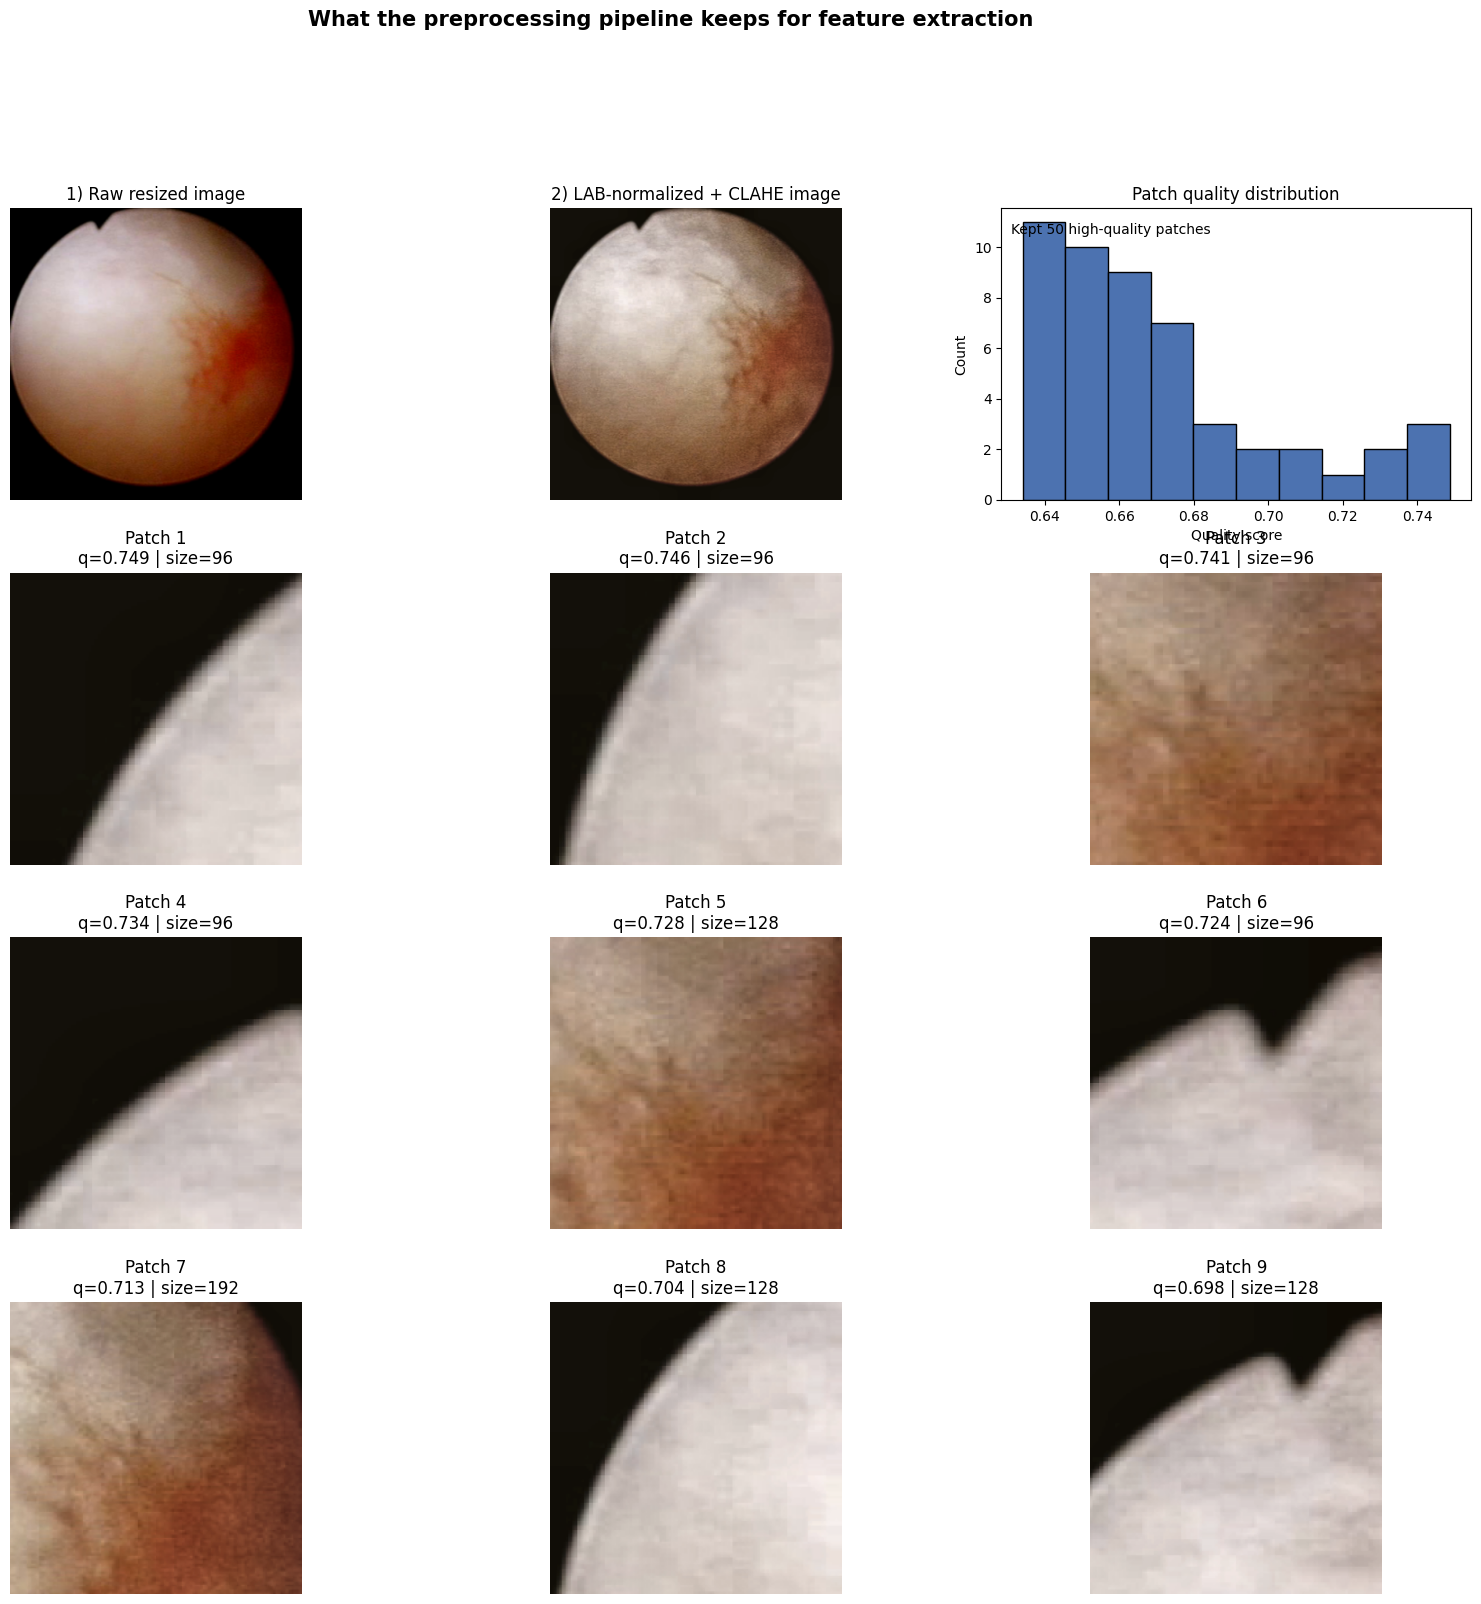

How to read this:
- Raw image: the original image after resizing to a manageable resolution.
- Normalized image: color-rebalanced using LAB matching + CLAHE.
- Patch quality plot: higher scores are tissue-rich, sharper, and less background-heavy.
- Patch grid: the highest-ranked patches that will be sent to the feature extractor.


In [5]:
def bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def show_image(ax, img, title):
    ax.imshow(bgr_to_rgb(img))
    ax.set_title(title)
    ax.axis("off")


if raw_img is not None:
    fig = plt.figure(figsize=(20, 18))
    gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.25, wspace=0.15)

    ax1 = fig.add_subplot(gs[0, 0])
    show_image(ax1, raw_img, "1) Raw resized image")

    ax2 = fig.add_subplot(gs[0, 1])
    show_image(ax2, norm_img, "2) LAB-normalized + CLAHE image")

    ax3 = fig.add_subplot(gs[0, 2])
    if patches:
        qualities = [q for _, q, _ in patches]
        ax3.hist(qualities, bins=min(10, len(qualities)), color="#4C72B0", edgecolor="black")
        ax3.set_title("Patch quality distribution")
        ax3.set_xlabel("Quality score")
        ax3.set_ylabel("Count")
        ax3.text(0.02, 0.95, f"Kept {len(patches)} high-quality patches", transform=ax3.transAxes, va="top")
    else:
        ax3.axis("off")
        ax3.text(0.5, 0.5, "No patches extracted", ha="center", va="center")

    # Show the first 9 patches after ranking
    max_show = min(9, len(patches))
    for i in range(max_show):
        row = 1 + i // 3
        col = i % 3
        ax = fig.add_subplot(gs[row, col])
        patch, quality, (x, y, scale) = patches[i]
        show_image(ax, patch, f"Patch {i+1}\nq={quality:.3f} | size={scale}")

    plt.suptitle("What the preprocessing pipeline keeps for feature extraction", fontsize=15, fontweight="bold", y=0.99)
    plt.show()

    print("How to read this:")
    print("- Raw image: the original image after resizing to a manageable resolution.")
    print("- Normalized image: color-rebalanced using LAB matching + CLAHE.")
    print("- Patch quality plot: higher scores are tissue-rich, sharper, and less background-heavy.")
    print("- Patch grid: the highest-ranked patches that will be sent to the feature extractor.")
else:
    print("No sample image available to visualize.")

## Summary

In `ensemble_v2`, preprocessing is not just resizing. The image is first normalized to reduce staining and lighting variation, then the code scans the image with multiple patch scales, filters out low-quality regions, and ranks the remaining patches by tissue quality. Only the best patches are kept for feature extraction.

The important idea for the viva is this: the model does not see the whole image at once. It sees a smaller set of high-quality tissue patches, and those patches are chosen deterministically and consistently so that the feature extractor gets stable, meaningful input.